# Function 5

## Check sys.path

In [1]:
# Checking that PYTHONPATH has been set to include local modules and included with sys.path

import os
try:
    print(f'PYTHONPATH:\n{os.environ['PYTHONPATH'].split(os.pathsep)}')
except KeyError:
    pass

import sys
print(f'\nsys.path:\n{'\n'.join(sys.path)}')

PYTHONPATH:
['C:\\Users\\antho\\Git\\LearningPython\\']

sys.path:
C:\Users\antho\Git\LearningPython
C:\Users\antho\AppData\Local\Python\pythoncore-3.14-64\python314.zip
C:\Users\antho\AppData\Local\Python\pythoncore-3.14-64\DLLs
C:\Users\antho\AppData\Local\Python\pythoncore-3.14-64\Lib
C:\Users\antho\AppData\Local\Python\pythoncore-3.14-64

C:\Users\antho\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages


## Imports

In [2]:
# Load extension to auto re-import script changes without having to restart Python kernel 
%load_ext autoreload

# Set autoreload = 2 (reloads everything before every cell execution)
%autoreload 2

# Import scripts common across all BBOFunction notebooks. '%run' ensures variables/imports become part of this notebook's namespace
%run imports.py

## Function 5 Description

*You’re tasked with optimising a four-variable black-box function that represents the yield of a chemical process in a factory. The function is typically unimodal, with a single peak where yield is maximised.*

*Your goal is to find the optimal combination of chemical inputs that delivers the highest possible yield, using systematic exploration and optimisation methods.*

## BBO parameters

In [3]:
func_no = 5
sub_week = 13

display(Markdown(f'**function number:** {func_no}'))
display(Markdown(f'**submission week:** {sub_week}'))

**function number:** 5

**submission week:** 13

## Load data

In [4]:
initial_len, y_pred, x_dim, x_col_names, df = data_helper.get_data(func_no, sub_week)

initial data points: 20
initial max: 1088.8596181962705
submission data points: 12
current max: 8662.405001248297 (from submission week: 7)
x_dim: 4


<br>**DataFrame:**

          x1        x2        x3        x4            y
26  0.999999  0.999999  0.999999  0.999999  8662.405001
29  0.999995  0.999995  0.999995  0.999995  8662.095012
28  0.999990  0.999990  0.999990  0.999990  8661.707538
27  0.999900  0.999900  0.999900  0.999900  8654.735478
31  0.999999  0.999999  0.999999  0.999415  8651.103680
30  0.995567  0.999999  0.999999  0.999999  8577.307779
25  0.739398  0.999999  0.999999  0.999999  5582.730606
24  0.430989  0.871952  0.999999  0.999999  3205.724972
23  0.390055  0.835503  1.000000  0.980370  2697.671664
22  0.321285  0.835912  0.989796  0.927768  2097.459893
21  0.305835  0.837423  0.976561  0.919045  1919.271935
20  0.300708  0.837945  0.971653  0.916257  1860.002080
15  0.224189  0.846480  0.879484  0.878516  1088.859618
18  0.119879  0.862540  0.643331  0.849804   431.612757
14  0.438933  0.774092  0.378167  0.933696   355.806818
4   0.836478  0.193610  0.663893  0.785649   258.370525
9   0.463442  0.630025  0.107906  0.957644   233

### Manually omit columns or other data amends (if desired)

## Distance between x points

In [5]:
dists, min_dist, max_dist = distance_helper.distances_between_points(x = df[x_col_names].values)

#display(Markdown('**Distances between x points:**'))
#for row in dists:
#    print(f'{row}')

display(Markdown(f'**min_dist:** {min_dist}'))
display(Markdown(f'**max_dist:** {max_dist}'))

**min_dist:** 8e-06

**max_dist:** 1.478882

## Tune Gaussian Process surrogate model

### Setup hyperparameters to trial (kernels, x_tansform and y_transform)

In [6]:
kernels = gaussian_process_helper.get_kernels(x_dim)

print(kernels.keys())

dict_keys(['Matern 2.5', 'Matern 1.5', 'Matern 0.5', 'RBF', 'Rational Quad', 'Periodic', 'Locally Periodic', 'Linear + RBF', 'Matern 2.5 + WhiteK', 'Matern 1.5 + WhiteK', 'Matern 0.5 + WhiteK', 'RBF + WhiteK', 'Rational Quad + WhiteK', 'Periodic + WhiteK', 'Locally Periodic + WhiteK', 'Linear + RBF + WhiteK', 'Local Sens + Mat 2.5 + WhiteK', 'Ridge + RQ + WhiteK', 'Local Sens + Ridge + Mat 2.5 + WhiteK'])


In [7]:
y_transforms = transform_helper.get_y_transformers()

print(y_transforms.keys())

dict_keys(['none', 'scaled', 'power', 'pow-scaled', 'logshift', 'logshift-scaled'])


In [8]:
x_transforms = transform_helper.get_x_transformers()

print(x_transforms.keys())

dict_keys(['none', 'scaled'])


### Manually override hyperparameter options (if desired)

### Perform the hyperparameter tuning

In [9]:
df_tuning_results, model_dict = gaussian_process_helper.tune_gaussian_process_surrogate(
    df = df,
    x_col_names = x_col_names,
    kernels = kernels,
    y_transforms = y_transforms,
    x_transforms = x_transforms,
)


Matern 2.5, x:none, y:none...
            y_t       mean_t      resid_t       std_t       y_pred
26  8662.405001  8662.404351    -0.000650    0.000217  8662.404351
29  8662.095012  8662.095010    -0.000002    0.000122  8662.095010
28  8661.707538  8661.708414     0.000875    0.000239  8661.708414
27  8654.735478  8654.675732    -0.059746    0.006579  8654.675732
31  8651.103680  8654.276935     3.173255    3.095585  8654.276935
30  8577.307779  8672.309832    95.002054    7.506996  8672.309832
25  5582.730606  3365.738766 -2216.991840  244.187132  3365.738766
24  3205.724972  2770.456903  -435.268069  114.388358  2770.456903
23  2697.671664  2925.385430   227.713767  100.392266  2925.385430
22  2097.459893  1926.439243  -171.020651   77.389074  1926.439243
21  1919.271935  1964.271285    44.999350   27.196277  1964.271285
20  1860.002080  1795.062448   -64.939632   35.256560  1795.062448
15  1088.859618   105.048753  -983.810865  315.096874   105.048753
18   431.612757     2.930983  -

C:\Users\antho\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__k1__constant_value is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


         y_t    mean_t   resid_t     std_t       y_pred
26  1.944353  1.944256 -0.000097  0.000394  8662.086292
29  1.944259  1.944192 -0.000067  0.000385  8661.872911
28  1.944141  1.944103 -0.000039  0.000380  8661.580236
27  1.942025  1.942783  0.000759  0.000928  8657.233893
31  1.940922  1.941957  0.001035  0.002136  8654.512454
30  1.918518  1.923859  0.005341  0.004794  8594.901597
25  1.009368  1.106092  0.096724  0.083535  5901.322495
24  0.287712  0.254400 -0.033313  0.018391  3095.998948
23  0.133468  0.150555  0.017087  0.012328  2753.954120
22 -0.048755 -0.052448 -0.003692  0.004773  2085.298706
21 -0.102853 -0.102155  0.000698  0.003942  1921.572240
20 -0.120847 -0.119020  0.001828  0.004177  1866.022238
15 -0.354965 -0.359099 -0.004134  0.019139  1075.243648
18 -0.554504 -0.565579 -0.011075  0.063935   395.133513
14 -0.577519 -0.556018  0.021501  0.062558   426.625989
4  -0.607101 -0.478241  0.128859  0.158882   682.810132
9  -0.614735 -0.724660 -0.109925  0.092054  -128

C:\Users\antho\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__k1__constant_value is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


         y_t    mean_t   resid_t     std_t       y_pred
26  1.944353  1.944256 -0.000097  0.000394  8662.086328
29  1.944259  1.944192 -0.000067  0.000385  8661.874969
28  1.944141  1.944104 -0.000038  0.000380  8661.583914
27  1.942025  1.942793  0.000768  0.000944  8657.265902
31  1.940922  1.941956  0.001034  0.002130  8654.508408
30  1.918518  1.924050  0.005532  0.004830  8595.528394
25  1.009368  1.107095  0.097727  0.084709  5904.625025
24  0.287712  0.253996 -0.033717  0.018754  3094.667906
23  0.133468  0.150999  0.017531  0.012491  2755.414806
22 -0.048755 -0.052637 -0.003881  0.004761  2084.675116
21 -0.102853 -0.102126  0.000727  0.003943  1921.667757
20 -0.120847 -0.118938  0.001910  0.004177  1866.292701
15 -0.354965 -0.358943 -0.003977  0.019191  1075.758957
18 -0.554504 -0.566453 -0.011949  0.064974   392.255973
14 -0.577519 -0.554374  0.023145  0.063418   432.041370
4  -0.607101 -0.469736  0.137364  0.161725   710.824651
9  -0.614735 -0.724968 -0.110233  0.093718  -129

...

C:\Users\antho\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__k1__k1__constant_value is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


         y_t    mean_t   resid_t     std_t       y_pred
26  1.377207  1.377200 -0.000007  0.000375  8662.278053
29  1.377191  1.377180 -0.000011  0.000372  8661.880215
28  1.377171  1.377154 -0.000017  0.000369  8661.386015
27  1.376814  1.376683 -0.000131  0.000388  8652.176244
31  1.376628  1.376228 -0.000400  0.000905  8643.313685
30  1.372832  1.373901  0.001069  0.000810  8598.041340
25  1.183936  1.157578 -0.026358  0.034384  5271.199186
24  0.943978  0.937332 -0.006646  0.031180  3164.456948
23  0.870262  0.882372  0.012110  0.017939  2777.799655
22  0.763525  0.763161 -0.000364  0.001520  2095.665595
21  0.726089  0.726108  0.000018  0.000419  1919.355537
20  0.712890  0.712897  0.000007  0.000536  1860.034490
15  0.489768  0.490276  0.000509  0.012649  1090.695083
18  0.113867  0.098745 -0.015121  0.074206   422.543681
14  0.036961 -0.057917 -0.094878  0.128292   294.483774
4  -0.089261 -0.079068  0.010193  0.371755   403.503875
9  -0.129335 -0.155805 -0.026470  0.239575   260

C:\Users\antho\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__k1__k1__constant_value is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


         y_t    mean_t   resid_t     std_t       y_pred
26  9.162045  9.162070  0.000025  0.000362  8662.642625
29  9.162012  9.162033  0.000021  0.000361  8662.291653
28  9.161972  9.161987  0.000015  0.000360  8661.853570
27  9.161240  9.161162 -0.000077  0.000358  8653.999444
31  9.160858  9.160538 -0.000320  0.000510  8648.055318
30  9.153074  9.154000  0.000926  0.000818  8586.063569
25  8.771657  8.768341 -0.003316  0.021980  5562.932820
24  8.311851  8.302384 -0.009467  0.009940  3167.557632
23  8.178579  8.188383  0.009804  0.007603  2732.885808
22  7.994152  7.993663 -0.000489  0.001330  2096.013020
21  7.932143  7.932132 -0.000010  0.000411  1919.243859
20  7.910634  7.910702  0.000068  0.000523  1860.187421
15  7.578133  7.578839  0.000706  0.008990  1090.318594
18  7.168371  7.183762  0.015391  0.046166   453.144401
14  7.108181  7.026152 -0.082029  0.045304   260.729505
4   7.025082  6.928680 -0.096402  0.144015   165.664196
9   7.002465  6.998302 -0.004164  0.104793   234

C:\Users\antho\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__k1__k1__constant_value is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


## Analytical Leave-One-Out Cross-Validation (LOOCV) Model Results

In [10]:
# Sort df_tuning_results:
# Mean-Square_Error (MSE) - The "best" kernel is the one with the lowest MSE    
# Log-Marginal Likelihood (LML) - The "best" kernel is the one with the highest LML
sort_columns = [Y_SMSE_TOP, Y_SMSE, Z_SMSE, LML]
sort_orders  = [      True,   True,   True, False]

#sort_columns = [Y_SMSE, Z_SMSE, LML]
#sort_orders  = [  True,   True, False]

df_tuning_results_sorted = df_tuning_results.sort_values(by=sort_columns, ascending=sort_orders)

# Format numeric display columns
display_cols = [MODEL, Z_SMSE, Y_SMSE, Y_SMSE_TOP, LML, KERNEL_PARAMS ]
for col in display_cols:
    df_tuning_results_sorted[col] = df_tuning_results_sorted[col].apply(format_sig_figs)

print(df_tuning_results_sorted[display_cols].to_string(index=False))

                                                             Model      Z_SMSE      Y_SMSE  Y_SMSE_TOP       LML                                                                                                                                                                                Kernel_Params
                            Locally Periodic, x:scaled, y:logshift  0.00901125 0.000661952 3.18332e-06   46.8318                                                                                    4.66**2 * RBF(len_scale=[12.4, 2e+03, 1e+05, 5.93e+04]) + ExpSineSquared(len_scale=2.6, periodicity=15.8)
                                Linear + RBF, x:scaled, y:logshift  0.00247568 0.000178239  4.2717e-06   52.6245                                                                                                                 DotProduct(sigma_0=8.3) + 0.741**2 * RBF(len_scale=[2.39, 3.14, 2.23, 2.21])
                                  Linear + RBF, x:none, y:logshift  0.00242516 0.000175427 5.8

## LOOCV Detailed Results for best model (Optionally override auto selected best model)

In [17]:
best_model_name = df_tuning_results_sorted[MODEL].iloc[0]

# Manually overriding best_model (optional)
override_model_name = "Linear + RBF, x:scaled, y:logshift" # None

if not override_model_name is None:
    display(Markdown(f'<span style="color:red">**Warning: Manually overriding best model from "{best_model_name}" to "{override_model_name}"**</span>'))
    best_model_name = override_model_name
    
best_model_dict = model_dict[best_model_name]
best_model = best_model_dict[MODEL]
x_transform = best_model_dict[X_TRANSFORM]
y_transform = best_model_dict[Y_TRANSFORM]

display(Markdown(f'<br>**Best model:**<br>{best_model_name}'))

params_str = extract_optimised_kernel_params_str(best_model)
display(Markdown(f'**Optimised parameters:**'))
print(params_str) # Own print() since it contains **

best_loocv_results = best_model_dict[LOOCV]

# Add the best model LOOCV results to df for easier display 
for label, content in best_loocv_results.items():
    df[label] = content

display(Markdown(f'<br>**LOOCV Predictions using best model:**<br>'))
print(df)

<span style="color:red">**Warning: Manually overriding best model from "Locally Periodic, x:scaled, y:logshift" to "Linear + RBF, x:scaled, y:logshift"**</span>

<br>**Best model:**<br>Linear + RBF, x:scaled, y:logshift

**Optimised parameters:**

DotProduct(sigma_0=8.3) + 0.741**2 * RBF(len_scale=[2.39, 3.14, 2.23, 2.21])


<br>**LOOCV Predictions using best model:**<br>

          x1        x2        x3        x4            y       y_t    mean_t  \
26  0.999999  0.999999  0.999999  0.999999  8662.405001  9.162045  9.162053   
29  0.999995  0.999995  0.999995  0.999995  8662.095012  9.162012  9.162019   
28  0.999990  0.999990  0.999990  0.999990  8661.707538  9.161972  9.161977   
27  0.999900  0.999900  0.999900  0.999900  8654.735478  9.161240  9.161213   
31  0.999999  0.999999  0.999999  0.999415  8651.103680  9.160858  9.160755   
30  0.995567  0.999999  0.999999  0.999999  8577.307779  9.153074  9.153343   
25  0.739398  0.999999  0.999999  0.999999  5582.730606  8.771657  8.770531   
24  0.430989  0.871952  0.999999  0.999999  3205.724972  8.311851  8.307429   
23  0.390055  0.835503  1.000000  0.980370  2697.671664  8.178579  8.183568   
22  0.321285  0.835912  0.989796  0.927768  2097.459893  7.994152  7.994242   
21  0.305835  0.837423  0.976561  0.919045  1919.271935  7.932143  7.932104   
20  0.300708  0.837945  0.971653  0.916257  1860.002

## y and y_t (y transformed) plots

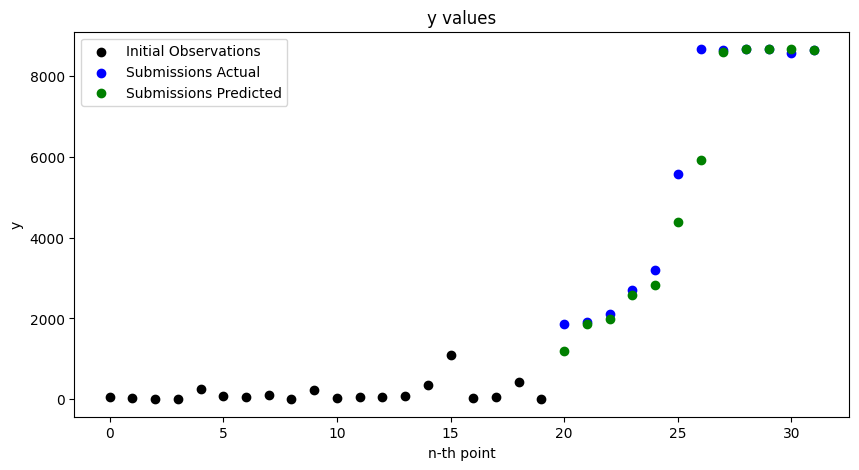

In [18]:
plot_helper.sequence_plot(df["y"], initial_len, y_pred)

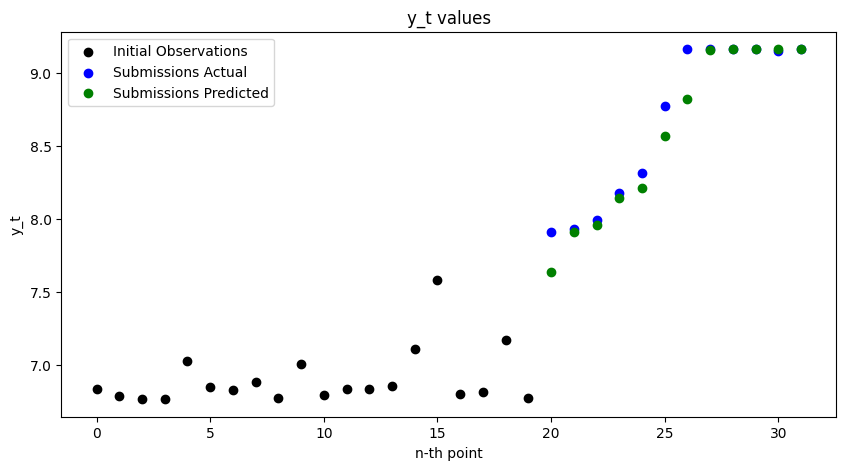

In [19]:
y_t_pred = y_transform.transform(y_pred)
plot_helper.sequence_plot(df["y_t"], initial_len, y_t_pred)

## Determine next evaluation point

### Create grid

In [20]:
x_grid = grid_helper.hypercube_grid([20, 20, 20, 20], x_col_names)

len(x_grid): 194481


### Maximise UCB and EI acquisition functions

In [21]:
# Small xi (0.0 – 0.01) - Exploitation dominant
# Moderate xi (0.01 – 0.1) - Balanced
# Large xi (0.5+) Strong exploration
ei_xis = [ 2, 1, 0.5, 0.1, 0.05, 0.01, 0.005, 0.001, 0 ]
ucb_betas = [ 10, 5, 2, 1, 0.5, 0.1, 0.05, 0.01, 0 ]
acq_fns = acquisition_fns_helper.get_acq_fns(df, y_transform, ei_xis = ei_xis, ucb_betas = ucb_betas)

# Bespoke bounds to force suggested next x near current x_best:
override_bounds = None # E.g. [(0.5, 0.9), (0.1, 0.4), ...]

if not override_bounds is None:
    display(Markdown(f'<span style="color:red">**Warning: Manually overriding acquisition function optimisation bounds to "{override_bounds}"**</span>'))
    
df_acq_results = acquisition_fns_helper.determine_next_eval_points(df, best_model, x_grid, x_col_names, x_transform, y_transform, x_dim, acq_fns, bounds = override_bounds, opt_trials=1000)

EI trans space (xi=2)...
Acq Fn([0.999999 0.999999 0.999999 0.      ]) = 1.0939869210284578e-21, distance: 0.5986163283233445, y_t_best: [7.69038186], y_best: [1484.03676168]
EI trans space (xi=1)...
Acq Fn([0.999999 0.999999 0.       0.999999]) = 2.062184613255264e-12, distance: 0.641592124508147, y_t_best: [7.78113508], y_best: [1694.58968636]
EI trans space (xi=0.5)...
Acq Fn([0.999999 0.999999 0.       0.999999]) = 9.11883022046368e-09, distance: 0.641592124508147, y_t_best: [7.78113508], y_best: [1694.58968636]
EI trans space (xi=0.1)...
Acq Fn([0.999999 0.       0.999999 0.999999]) = 4.041626632080749e-06, distance: 0.4723740411221888, y_t_best: [8.20218286], y_best: [2924.69077474]
EI trans space (xi=0.05)...
Acq Fn([0.999999 0.       0.999999 0.999999]) = 8.64157683261294e-06, distance: 0.4723740411221888, y_t_best: [8.20218286], y_best: [2924.69077474]
EI trans space (xi=0.01)...
Acq Fn([0.999999 0.       0.999999 0.999999]) = 1.5536033793639214e-05, distance: 0.47237404112218

### Display the acquisition function results

In [22]:
display(Markdown(f'<br>**EXISTING BEST:**'))
print(f'Actual y: {df['y'].iloc[0]}\nActual y_t: {df['y_t'].iloc[0]}\nx: {df[x_col_names].iloc[0].values}')

x_t = x_transform.transform(df[x_col_names].iloc[0].values.reshape(-1,x_dim))
y_t_mean, y_t_std = best_model.predict(np.atleast_2d(x_t), return_std=True)
y_mean, y_std = y_transform.inverse_transform_dist(y_t_mean, y_t_std)

display(Markdown(f'<br>**Model\'s [{best_model_name}] prediction at x corresponding to the best y.**'))
print(f'NB. the model was already trained using this x point. This is just a sense check for modelling accuracy rather than predictive ability.')
print(f'y_t_mean: {y_t_mean}, y_t_std: {y_t_std}\ny_mean: {y_mean}\n')

# Add a y_mean ranking
df_acq_results['y_mean rank'] = df_acq_results['y_mean'].rank(ascending=False, method='min').astype(int)

display(Markdown(f'<br>**FUNCTION {func_no} SUBMISSION WEEK {sub_week}:**<br>'))
print(df_acq_results.to_string(index=False))

<br>**EXISTING BEST:**

Actual y: 8662.405001248297
Actual y_t: 9.162044818564494
x: [0.999999 0.999999 0.999999 0.999999]


<br>**Model's [Linear + RBF, x:scaled, y:logshift] prediction at x corresponding to the best y.**

NB. the model was already trained using this x point. This is just a sense check for modelling accuracy rather than predictive ability.
y_t_mean: [9.1620505], y_t_std: [5.39127883e-05]
y_mean: [8662.4591888]



<br>**FUNCTION 5 SUBMISSION WEEK 13:**<br>

                     acq_fn            ['x1', 'x2', 'x3', 'x4']  distance  y_t_mean      y_mean  y_mean rank
      EI trans space (xi=2) 0.999999-0.999999-0.999999-0.000000  0.598616  7.690382 1484.036762           26
      EI trans space (xi=1) 0.999999-0.999999-0.000000-0.999999  0.641592  7.781135 1694.589686           23
    EI trans space (xi=0.5) 0.999999-0.999999-0.000000-0.999999  0.641592  7.781135 1694.589686           23
    EI trans space (xi=0.1) 0.999999-0.000000-0.999999-0.999999  0.472374  8.202183 2924.690775            8
   EI trans space (xi=0.05) 0.999999-0.000000-0.999999-0.999999  0.472374  8.202183 2924.690775            8
   EI trans space (xi=0.01) 0.999999-0.000000-0.999999-0.999999  0.472374  8.202183 2924.690775            8
  EI trans space (xi=0.005) 0.999999-0.000000-0.999999-0.999999  0.472374  8.202183 2924.690775            8
  EI trans space (xi=0.001) 0.999999-0.000000-0.999999-0.999999  0.472374  8.202183 2924.690775            8
      EI trans spac

## Manually calculating the prediction at an x point (Helper method)